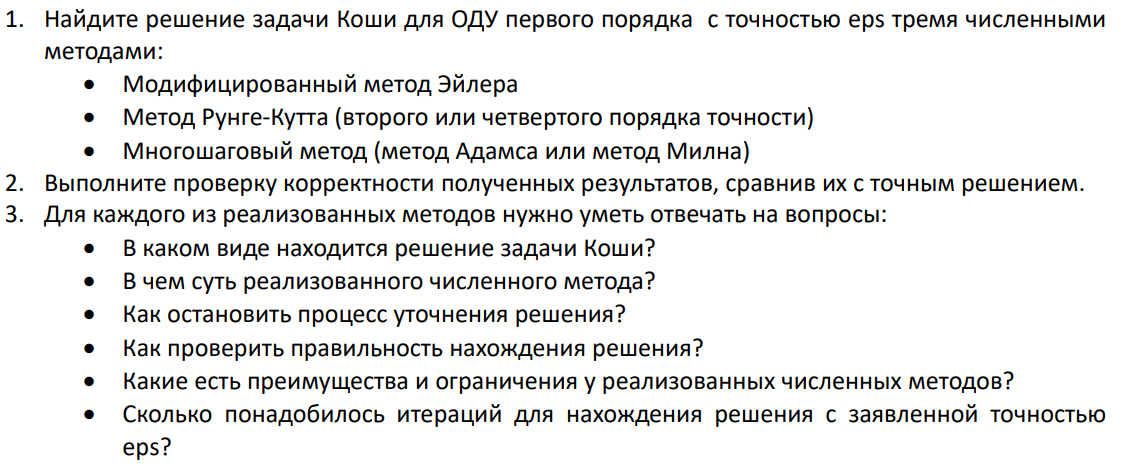




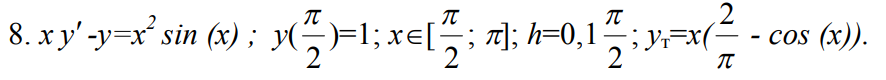

In [133]:
import math
import numpy as np

MAX_ITER = 20
EPS = 1e-10

x0 = math.pi / 2
y0 = 1.0
a = x0
b = math.pi
h = 0.1

x_vals = int(round((b - a) / h))
n_nodes = x_vals + 1

def f(x,y):
    return y / x + x * math.sin(x)


def y_exact(x):
    return x * (2 / math.pi - math.cos(x))


def mod_euler(x0,y0,h):
    x = x0
    y = y0
    result = [(x,y)]

    for k in range(x_vals):
        x_next = x + h
        y_pred = y + h * f(x,y)

        y_next = y + (h / 2) * (f(x,y) + f(x_next, y_pred))
        x = x_next
        y = y_next

        result.append((x,y))
    
    return result

print("Метод модифицированный Эйлера\n")
euler = (mod_euler(x0,y0,h))

max_err_euler = 0
print(f"{'№':^3} {'x':^14} {'y_числ':^18} {'y_t (точное)':^18} {'|Разность|':^18}")

for i in range(len(euler)):
    x_val = euler[i][0]
    y_num = euler[i][1]
    y_t = y_exact(x_val)
    diff = abs(y_num - y_t)
    max_err_euler = max(max_err_euler, diff)
    print(f"{i:^3} {x_val:^14.10f} {y_num:^18.10f} {y_t:^18.10f} {diff:^18.2e}")

Метод модифицированный Эйлера

 №        x              y_числ          y_t (точное)        |Разность|    
 0   1.5707963268     1.0000000000       1.0000000000         1.11e-16     
 1   1.6707963268     1.2300250003       1.2304632831         4.38e-04     
 2   1.7707963268     1.4782355399       1.4791268757         8.91e-04     
 3   1.8707963268     1.7424894240       1.7438440488         1.35e-03     
 4   1.9707963268     2.0202885030       2.0221121476         1.82e-03     
 5   2.0707963268     2.3088086116       2.3111025305         2.29e-03     
 6   2.1707963268     2.6049346603       2.6076956706         2.76e-03     
 7   2.2707963268     2.9053004635       2.9085209985         3.22e-03     
 8   2.3707963268     3.2063328182       3.2100010032         3.67e-03     
 9   2.4707963268     3.5042992928       3.5083990461         4.10e-03     
10   2.5707963268     3.7953591245       3.7998702892         4.51e-03     
11   2.6707963268     4.0756165863       4.0805150933    

In [134]:
def runge_kutta_4(x0, y0, h, steps):
    x = x0
    y = y0
    
    result = [(x,y)]

    for k in range(steps):
        k1 = h * f(x, y)
        k2 = h * f(x + h / 2, y + k1 / 2)
        k3 = h * f(x + h / 2, y + k2 / 2)
        k4 = h * f(x + h, y + k3)

        x_next = x + h
        y_next = y + (1/6) * (k1 + 2 * (k2 + k3) + k4)

        x = x_next
        y = y_next

        result.append((x,y))
    
    return result

print("Метод Рунге-Кутта (4-го порядка)\n")
rk4 = runge_kutta_4(x0, y0, h, x_vals)

print(f"{'№':^3} {'x':^14} {'y_числ':^18} {'y_t (точное)':^18} {'|Разность|':^18}")

max_err_rk4 = 0
for i in range(len(rk4)):
    x_val = rk4[i][0]
    y_num = rk4[i][1]
    y_t = y_exact(x_val)
    diff = abs(y_num - y_t)
    max_err_rk4 = max(max_err_rk4, diff)
    print(f"{i:^3} {x_val:^14.10f} {y_num:^18.10f} {y_t:^18.10f} {diff:^18.2e}")

Метод Рунге-Кутта (4-го порядка)

 №        x              y_числ          y_t (точное)        |Разность|    
 0   1.5707963268     1.0000000000       1.0000000000         1.11e-16     
 1   1.6707963268     1.2304631939       1.2304632831         8.91e-08     
 2   1.7707963268     1.4791267082       1.4791268757         1.67e-07     
 3   1.8707963268     1.7438438124       1.7438440488         2.36e-07     
 4   1.9707963268     2.0221118501       2.0221121476         2.97e-07     
 5   2.0707963268     2.3111021791       2.3111025305         3.51e-07     
 6   2.1707963268     2.6076952712       2.6076956706         3.99e-07     
 7   2.2707963268     2.9085205562       2.9085209985         4.42e-07     
 8   2.3707963268     3.2100005225       3.2100010032         4.81e-07     
 9   2.4707963268     3.5083985308       3.5083990461         5.15e-07     
10   2.5707963268     3.7998697424       3.7998702892         5.47e-07     
11   2.6707963268     4.0805145175       4.0805150933 

In [135]:
def adams_pred_corr(x0, y0, h):
    start_points = runge_kutta_4(x0, y0, h, 3)
    result = list(start_points)
    f_values = [f(p[0], p[1]) for p in start_points]

    x_curr, y_curr = result[-1]

    for _ in range(x_vals - 3):
        x_next = x_curr + h

        y_pred = y_curr + (h / 24) * (
            55 * f_values[-1] -
            59 * f_values[-2] +
            37 * f_values[-3] -
            9 * f_values[-4]
        )

        y_old = y_pred

        for _ in range(MAX_ITER):
            f_next = f(x_next, y_old)

            y_new = y_curr + (h / 24) * (
                9 * f_next +
                19 * f_values[-1] -
                5 * f_values[-2] + 
                f_values[-3]
            )

            if abs(y_new - y_old) < EPS:
                y_old = y_new
                break
            
            y_old = y_new

        x_curr = x_next
        y_curr = y_old
        result.append((x_curr, y_curr))
        f_values.append(f(x_curr, y_curr))

    return result

adams = adams_pred_corr(x0, y0, h)

print("Метод Адамса")
print(f"{'№':^3} {'x':^14} {'y_числ':^18} {'y_t (точное)':^18} {'|Разность|':^18}")

max_err_adams = 0
for i in range(len(adams)):
    x_val = adams[i][0]
    y_num = adams[i][1]
    y_t = y_exact(x_val)
    diff = abs(y_num - y_t)
    max_err_adams = max(max_err_adams, diff)
    print(f"{i:^3} {x_val:^14.10f} {y_num:^18.10f} {y_t:^18.10f} {diff:^18.2e}")

Метод Адамса
 №        x              y_числ          y_t (точное)        |Разность|    
 0   1.5707963268     1.0000000000       1.0000000000         1.11e-16     
 1   1.6707963268     1.2304631939       1.2304632831         8.91e-08     
 2   1.7707963268     1.4791267082       1.4791268757         1.67e-07     
 3   1.8707963268     1.7438438124       1.7438440488         2.36e-07     
 4   1.9707963268     2.0221127346       2.0221121476         5.87e-07     
 5   2.0707963268     2.3111041271       2.3111025305         1.60e-06     
 6   2.1707963268     2.6076984472       2.6076956706         2.78e-06     
 7   2.2707963268     2.9085251167       2.9085209985         4.12e-06     
 8   2.3707963268     3.2100066125       3.2100010032         5.61e-06     
 9   2.4707963268     3.5084062810       3.5083990461         7.23e-06     
10   2.5707963268     3.7998792677       3.7998702892         8.98e-06     
11   2.6707963268     4.0805259150       4.0805150933         1.08e-05     

In [136]:
print(f"Модифицированный Эйлер: {max_err_euler:.6e}")
print(f"Рунге-Кутта 4 порядка:  {max_err_rk4:.6e}")
print(f"Метод Адамса:           {max_err_adams:.6e}")


Модифицированный Эйлер: 6.353103e-03
Рунге-Кутта 4 порядка:  6.977246e-07
Метод Адамса:           2.080299e-05
